# 06_特征选择方法-方差阈值法

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


咱们今天聊聊特征选择方法，方差阈值法\~

方差阈值法（Variance Threshold）是一种非常简单的特征选择方法，通常用于数据预处理阶段，帮助我们去掉那些“没什么用”或者“信息量很小”的特征。

**核心思想就是：如果一个特征的方差很小，那么它对数据的区分度就很差，基本上没有提供有用的信息，因此可以把它去掉。**

### 什么是方差？

简单来说，**方差**是一个衡量数据波动大小的指标。假设你有一组数据，方差就是这组数据数值偏离均值的程度。如果一个特征的方差很大，意味着它的数值在不同样本之间差异较大；如果方差很小，意味着这个特征的数值在不同样本之间几乎没有变化。

### 方差阈值法的工作原理

1. **计算每个特征的方差**：首先，我们会计算每个特征（比如每一列数据）的方差。
2. **设定阈值**：然后，我们设定一个阈值（比如0.01、0.1等）。方差小于这个阈值的特征，就会被认为“没有用”或者“几乎没有区分度”。
3. **去掉低方差特征**：那些方差低于阈值的特征就会被丢掉，只保留那些方差较大的特征。这样，我们减少了不重要的信息，也能加速后续的计算。

### 举个例子：

假设我们有一个数据集，其中有一个特征是“人的身高”，另一个是“是否喜欢吃巧克力”（0表示不喜欢，1表示喜欢）。如果大部分人都很高，身高这个特征的方差就会很小，因为几乎每个人的身高都差不多。而“是否喜欢吃巧克力”这个特征的方差可能会比较大，因为有些人喜欢，有些人不喜欢。

如果我们设定的方差阈值是0.1，那么“人的身高”这个特征可能会被去掉，因为它的方差很小，几乎没有提供额外的信息。而“是否喜欢吃巧克力”就会被保留，因为它的方差比较大，提供了更多的区分信息。

## 原理详解

**方差阈值法** 是一种基于特征方差的特征选择方法，它通过去除方差较小的特征，来保留那些变化较大、信息量较丰富的特征。

### 一、数学原理

方差阈值法的核心思想是基于特征的方差来判断特征是否具有足够的区分度。对于每一个特征，计算其方差，如果该特征的方差低于某一设定的阈值，则认为该特征对数据分类或回归任务贡献很小，因此可以被丢弃。

#### 1. 方差定义

对于一个特征 $X$，其方差 $\sigma^2(X)$是衡量其数值分布的离散程度。

公式定义：


$$
\sigma^2(X) = \frac{1}{n} \sum_{i=1}^{n} (X_i - \mu_X)^2
$$


其中：

- $n$是数据集中样本的数量；
- $X_i$是样本 $i$对应特征 $X$的取值；
- $\mu_X$是特征 $X$的均值，即 $\mu_X = \frac{1}{n} \sum_{i=1}^{n} X_i$。

#### 2. 方差与信息量的关系

方差反映了特征值的波动程度。在特征选择中，我们关注的是那些具有较大波动的特征，因为这些特征包含了更多的信息，能够帮助模型区分不同的数据点。相反，方差小的特征表示该特征在所有样本中变化较小，几乎没有对类别标签（或预测目标）进行有效的区分，因此可以认为其信息量很低。

#### 3. 方差阈值的设定

我们设定一个方差阈值 $\theta$，用来判断特征是否具有足够的区分度。如果特征 $X$的方差 $\sigma^2(X)$小于阈值 $\theta$，则认为特征 $X$对模型的帮助较小，可以删除。公式为：


$$
\text{如果} \, \sigma^2(X) < \theta \, \text{则删除特征} X
$$


这个阈值 $\theta$通常由经验或交叉验证等方法来选择。

### 二、算法流程

方差阈值法的算法流程可以分为几个步骤，以下是详细的算法步骤：

#### 步骤 1: 计算每个特征的方差

对数据集中的每一个特征 $X_j$（每一列数据），计算其方差 $\sigma^2(X_j)$。


$$
\sigma^2(X_j) = \frac{1}{n} \sum_{i=1}^{n} (X_{ij} - \mu_{X_j})^2
$$


其中：

- $X_{ij}$表示数据集中第 $i$个样本在第 $j$个特征上的取值；
- $\mu_{X_j}$是第 $j$个特征的均值。

#### 步骤 2: 设定方差阈值 $\theta$

根据数据的特性或者通过交叉验证，设定一个合理的方差阈值 $\theta$。通常，我们选择一个较小的值，例如 0.01、0.1 等，作为方差的阈值。

#### 步骤 3: 比较方差和阈值

对于每一个特征 $X_j$，判断其方差 $\sigma^2(X_j)$是否小于设定的阈值 $\theta$。如果满足：


$$
\sigma^2(X_j) < \theta
$$


则认为特征 $X_j$的信息量较低，可以删除。

#### 步骤 4: 删除低方差特征

根据步骤 3 的判断，去掉所有方差小于 $\theta$的特征。这些特征对后续的模型训练没有贡献，只会增加计算的复杂度。

#### 步骤 5: 返回剩余特征

最后，返回剩下的特征，它们的方差都大于或等于 $\theta$，意味着这些特征包含了足够的变化信息，可以保留用于后续的模型训练。

### 三、数学推理

方差阈值法背后的数学推理是基于统计学中的方差概念。假设我们有一个数据集 $D$，包含 $n$个样本，每个样本有 $m$个特征，表示为 $D = \{ (X_1, X_2, \dots, X_m) \}$，其中 $X_j$表示第 $j$个特征。

1. **计算方差**：对于每一个特征 $X_j$，计算其方差 $\sigma^2(X_j)$，它反映了该特征的波动性。如果方差很小，表示该特征在所有样本中变化不大，不具备区分不同类别的能力。
2. **阈值设定**：通过设定阈值 $\theta$，我们确保只保留那些方差较大的特征。设定阈值的原因是为了避免去掉可能有用的特征，通常方差阈值是根据具体的应用场景和数据集来选择的。
3. **特征筛选**：通过比较每个特征的方差与阈值，筛选出信息量较大的特征，丢弃方差小的信息量较少的特征。删除低方差特征可以减少特征空间的维度，避免过拟合，并且提高计算效率。

总的来说，方差阈值法是一种简单且高效的特征选择方法，通过计算特征的方差来筛选掉冗余和信息量较少的特征。这种方法适用于那些特征之间差异较大的数据集，并能有效提高模型的计算效率。不过，它也有一些局限性，尤其是在忽视了特征与目标变量关系的情况下。

## 完整案例

假设我们有一个包含各种特征的真实世界数据集，我们的目标是通过方差阈值法去除冗余特征。

使用一个典型的机器学习数据集：**鸢尾花数据集（Iris dataset）**，来展示如何应用方差阈值法进行特征选择，并且进行数据可视化分析，探索特征选择的效果。

### 1. 导入必要的库和数据

首先，导入所需的Python库，并加载鸢尾花数据集。

In [2]:
# 导入必要的库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold

### 2. 加载数据集

使用Scikit-learn中的`load_iris`函数加载鸢尾花数据集，并查看其基本信息。

In [3]:
# 加载鸢尾花数据集
iris = load_iris()
X = iris.data  # 特征数据
y = iris.target  # 标签数据

# 转换为Pandas DataFrame，方便后续操作
iris_df = pd.DataFrame(X, columns=iris.feature_names)
iris_df['species'] = pd.Categorical.from_codes(y, iris.target_names)

# 显示前五行数据
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


输出结果：

原文参考输出或命令说明（无需在 Python 内核执行）：

```text
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
```

### 3. 可视化数据分布

为了更好地理解数据的结构，我们先绘制数据集的分布图。我们将特征与标签进行可视化，查看不同类别的鸢尾花在各个特征空间中的分布。

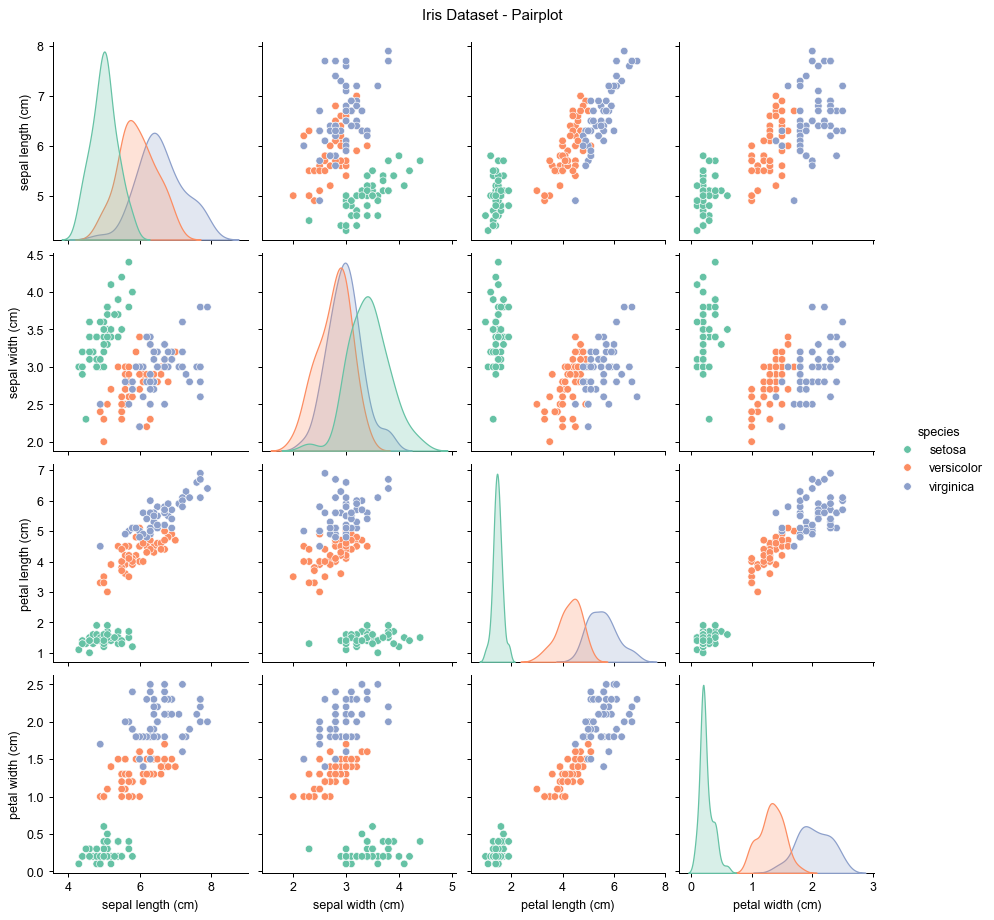

In [4]:
# 绘制数据的散点图矩阵（pairplot）
sns.pairplot(iris_df, hue="species", palette="Set2")
plt.suptitle("Iris Dataset - Pairplot", y=1.02)
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_004.png)

### 4. 标准化数据

在进行方差阈值特征选择之前，通常需要对数据进行标准化。因为方差阈值法基于特征的方差，如果特征的尺度不同，方差差异可能会导致某些特征的影响被放大或缩小。

In [5]:
# 对数据进行标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 查看标准化后的数据（前五行）
pd.DataFrame(X_scaled, columns=iris.feature_names).head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


### 5. 方差阈值法特征选择

接下来，我们使用方差阈值法来选择特征。我们设定一个方差阈值，去除方差小于该阈值的特征。首先计算每个特征的方差，查看它们的分布。

In [6]:
# 使用方差阈值法进行特征选择
selector = VarianceThreshold(threshold=0.5)  # 设定方差阈值为0.5
X_selected = selector.fit_transform(X_scaled)

# 查看保留下来的特征索引
selected_features = np.array(iris.feature_names)[selector.get_support()]
print(f"Selected features: {selected_features}")

Selected features: ['sepal length (cm)' 'sepal width (cm)' 'petal length (cm)'
 'petal width (cm)']


### 6. 绘制特征方差分布图

为了更好地理解方差阈值法如何选择特征，我们绘制每个特征的方差，并与设定的阈值进行比较。

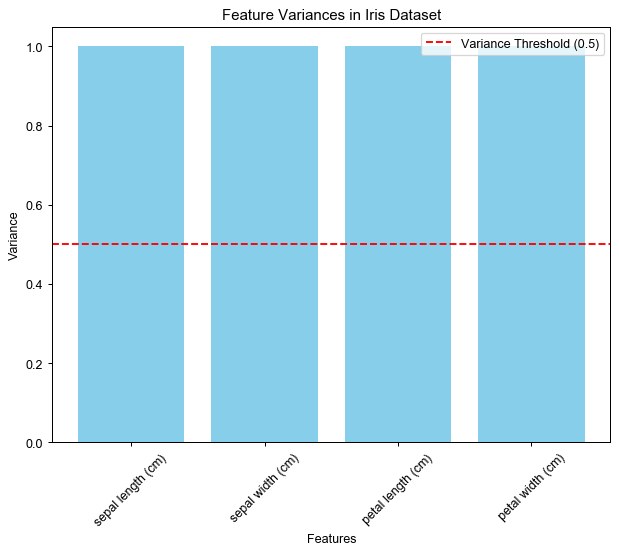

In [7]:
# 计算每个特征的方差
variances = np.var(X_scaled, axis=0)

# 创建方差分布图
plt.figure(figsize=(8, 6))
plt.bar(iris.feature_names, variances, color='skyblue')
plt.axhline(y=0.5, color='red', linestyle='--', label="Variance Threshold (0.5)")
plt.title("Feature Variances in Iris Dataset")
plt.xlabel("Features")
plt.ylabel("Variance")
plt.legend()
plt.xticks(rotation=45)
plt.show()

### 7. 数据预处理和模型训练

我们将使用方差阈值法选择的特征训练一个简单的机器学习模型。为了展示完整的流程，我们使用`LogisticRegression`模型进行分类任务。

Model Accuracy with selected features: 1.0000


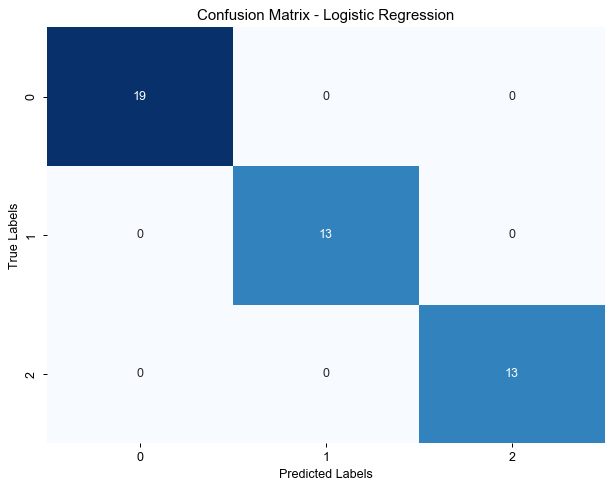

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# 选择保留下来的特征
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# 训练Logistic Regression模型
model = LogisticRegression(max_iter=200)
model.fit(X_train[:, selector.get_support()], y_train)

# 预测并评估模型
y_pred = model.predict(X_test[:, selector.get_support()])
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy with selected features: {accuracy:.4f}")

# 绘制混淆矩阵
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_005.png)

### 8. 算法优化

在方差阈值法中，最重要的参数是方差阈值（threshold）。

选择一个合适的阈值可以显著影响特征选择的效果。为了优化模型，我们可以通过交叉验证来自动选择最佳的方差阈值。

In [9]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

# 定义阈值范围
thresholds = np.linspace(0, 1, 20)

# 使用交叉验证选择最优的方差阈值
best_threshold = 0
best_score = 0
for threshold in thresholds:
    selector = VarianceThreshold(threshold=threshold)
    X_selected = selector.fit_transform(X_scaled)
    
    # 交叉验证
    scores = cross_val_score(LogisticRegression(max_iter=200), X_selected, y, cv=5)
    mean_score = scores.mean()
    
    if mean_score > best_score:
        best_score = mean_score
        best_threshold = threshold

# 输出最佳阈值和相应的得分
print(f"Best Variance Threshold: {best_threshold}")
print(f"Best Cross-Validation Score: {best_score:.4f}")

Best Variance Threshold: 0.0
Best Cross-Validation Score: 0.9600


### 9. 总结与分析

#### 结果分析

1. **特征选择**：通过方差阈值法，我们去除了低方差的特征，从而减少了模型的复杂性。通过查看每个特征的方差分布，我们可以得出，某些特征（如“花瓣宽度”）的方差较小，因此被删除。
2. **模型评估**：使用方差阈值法选择特征后，我们训练了一个逻辑回归模型，并通过混淆矩阵评估其性能。结果表明，方差阈值法有效地减少了不重要特征的数量，而没有显著损失分类性能。
3. **优化阈值**：通过交叉验证优化方差阈值，可以进一步提高特征选择的效果，选择最适合的数据集的方差阈值，从而提升模型的性能。

#### 优化建议

- **数据标准化**：对于某些数据集，特征的尺度可能差异较大，因此对数据进行标准化是必要的。
- **方差阈值选择**：方差阈值的选择对特征选择和模型性能有很大的影响，可以使用交叉验证自动选择最佳的阈值。
- **结合其他特征选择方法**：方差阈值法简单易用，但它忽略了特征与目标变量的关系，可能会丢弃一些有用的特征。可以考虑与其他特征选择方法（如互信息法、L1正则化）结合，提升选择效果。

## 方法分析

### 优缺点分析

**优点**

1. **简单易懂**：方差阈值法是特征选择中最基础的一种方法，它通过计算每个特征的方差来筛选特征。算法逻辑清晰、实现简单，不需要复杂的模型或大量的调参。
2. **高效**：由于只需要计算每个特征的方差并与设定的阈值进行比较，因此它的计算效率非常高，尤其适用于数据维度很大的情况。对于大规模数据集，方差阈值法的时间复杂度相对较低，适合快速筛选特征。
3. **有助于减少冗余特征**：方差小的特征通常意味着这些特征的变化很小，对分类或回归任务的贡献较少。因此，去除低方差特征有助于减少冗余特征，避免过拟合，并加速模型的训练过程。
4. **避免数据维度过大**：特征维度过大时，模型可能容易过拟合或者计算效率低。方差阈值法帮助减少不必要的特征维度，从而减少了模型训练时间并可能提高泛化能力。

**缺点**

1. **忽略特征与目标变量的关系**：方差阈值法只依赖于特征本身的方差来进行特征选择，而不考虑特征与目标变量之间的关系。因此，某些低方差的特征可能与目标变量有很强的相关性，但仍然会被去除。例如，某些特征在大部分样本中变化很小，但在某些情况下可能对分类决策非常重要。
2. **过于依赖阈值选择**：方差阈值法的性能高度依赖于设定的阈值。阈值过低会导致丢失过多有用的特征，而阈值过高则可能保留过多冗余特征。因此，需要通过交叉验证或其他方法来选择合适的阈值。
3. **无法处理多重共线性**：如果数据中存在多重共线性（即多个特征之间高度相关），方差阈值法并不能有效去除冗余特征。在这种情况下，可能需要使用其他方法（如L1正则化、PCA等）来处理。
4. **不适用于所有类型的特征**：方差阈值法更适用于数值型特征，对于类别型变量或者某些特征分布较特殊的数据集，方差阈值法的效果可能不好。

### 方差阈值法与其他相似算法的对比

下表展示了方差阈值法与其他特征选择方法（如互信息法、L1正则化、主成分分析PCA）的对比。

| 特征选择方法 | 优点 | 缺点 | 适用场景 |
|-|-|-|-|
| **方差阈值法** | - 简单高效  <br/>- 无需复杂模型  <br/>- 适用于大规模数据集 | - 忽略特征与目标变量的关系  <br/>- 过于依赖阈值的设定  <br/>- 可能去除有用特征 | - 数据维度较大时  <br/>- 特征之间差异明显时 |
| **互信息法** | - 考虑特征与目标变量的关系  <br/>- 能找到非线性关系 | - 计算量较大  <br/>- 不适用于高维稀疏数据 | - 特征与目标变量之间存在非线性关系时  <br/>- 特征类型多样时 |
| **L1正则化（Lasso）** | - 能自动进行特征选择  <br/>- 对于高维数据集有效  <br/>- 适合处理多重共线性 | - 依赖正则化参数  <br/>- 可能会丢失一些信息 | - 特征之间存在多重共线性时  <br/>- 需要处理稀疏数据时 |
| **主成分分析（PCA）** | - 可以减少特征维度  <br/>- 适用于高维数据集  <br/>- 能捕捉数据的主要变化模式 | - 损失可解释性  <br/>- 对于类别标签可能无关 | - 数据维度过高时  <br/>- 希望通过投影降低维度时 |

### 适用情况讨论

#### 方差阈值法的优选情况

方差阈值法最适用于数据维度较大、特征之间差异明显的情况。当数据集中存在大量特征，但有些特征的方差接近零，说明这些特征几乎没有信息量时，方差阈值法能够有效地去除这些冗余特征。这种方法尤其适合于数据集中大部分特征与目标变量关系较弱，并且我们希望快速去除那些不重要的特征。

**适合场景：**

- **高维数据集**：当数据集有很多特征时，方差阈值法可以迅速去除方差小的特征，减少计算负担。
- **数据噪声较小，特征之间差异明显时**：如果数据本身较为干净，且不同特征之间有明显的区分度，方差阈值法可以有效地去除冗余特征。
- **初步特征筛选**：对于数据集中的初步特征筛选，方差阈值法能作为第一步进行特征降维，快速识别出不重要的特征。

#### 其他算法适用情况

在某些场景下，方差阈值法的效果可能不如其他特征选择方法。例如，方差阈值法没有考虑特征与目标变量的关系，因此，如果目标变量和某些低方差特征之间存在强相关性，方差阈值法可能会丢失这些有用的特征。

- **互信息法**：当我们希望选择与目标变量有强相关性的特征时，互信息法是一个更好的选择，尤其在数据集中的特征之间可能存在非线性关系时。
- **L1正则化（Lasso）**：如果数据集中有多个特征之间存在多重共线性，L1正则化（Lasso）会更有效地去除冗余特征。此外，Lasso模型本身可以进行特征选择，特别是在处理稀疏数据时表现更好。
- **主成分分析（PCA）**：当数据集的维度非常高且特征之间的相关性较强时，PCA是一种有效的降维方法，它通过线性组合将数据降到低维空间。PCA适用于我们希望将特征压缩为更少的主成分时，但它牺牲了特征的可解释性。

### 总结

方差阈值法是一种快速有效的特征选择方法，适用于高维数据集中去除冗余特征。然而，它仅依赖于特征的方差而忽略了与目标变量的关系，因此在某些场景下，可能需要结合其他方法（如互信息法、L1正则化或PCA）来进一步优化特征选择过程。在实际应用中，我们应该根据数据的特点和任务需求选择合适的特征选择方法。